In [ ]:
!pip install torch scikit-learn -q

In [23]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("/content/cleaned_sleep_apnea.csv")

df.head()

,subject_id,night_id,epoch_index,age,bmi,acc_mean,acc_std,hr_mean,hr_std,spo2_mean,spo2_min,is_apnea_event,severity_label
0,S0000,S0000_N0,0.0,60.0,32.8,5.31,1.36,54.9,2.84,93.5,93.4,0.0,moderate
1,S0000,S0000_N0,1.0,60.0,32.8,5.70,0.71,53.8,1.89,95.3,93.9,0.0,moderate
2,S0000,S0000_N0,2.0,60.0,32.8,5.11,1.28,61.3,3.78,95.4,94.8,0.0,moderate
3,S0000,S0000_N0,3.0,60.0,32.8,5.00,1.28,56.9,2.24,94.7,93.1,0.0,moderate
4,S0000,S0000_N0,4.0,60.0,32.8,3.56,0.73,57.4,2.27,95.0,94.2,0.0,moderate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58726 entries, 0 to 58725
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      58726 non-null  object 
 1   night_id        58726 non-null  object 
 2   epoch_index     58725 non-null  float64
 3   age             58725 non-null  float64
 4   bmi             58725 non-null  float64
 5   acc_mean        58725 non-null  float64
 6   acc_std         58725 non-null  float64
 7   hr_mean         58725 non-null  float64
 8   hr_std          58725 non-null  float64
 9   spo2_mean       58725 non-null  float64
 10  spo2_min        58725 non-null  float64
 11  is_apnea_event  58725 non-null  float64
 12  severity_label  58725 non-null  object 
dtypes: float64(10), object(3)
memory usage: 5.8+ MB


In [ ]:
df = df.sort_values(
    ["subject_id", "night_id", "epoch_index"]
).reset_index(drop=True)

In [ ]:
encoder = LabelEncoder()

df["severity_label"] = encoder.fit_transform(df["severity_label"])

In [ ]:
features = [
    "age",
    "bmi",
    "acc_mean",
    "acc_std",
    "hr_mean",
    "hr_std",
    "spo2_mean",
    "spo2_min",
    "is_apnea_event"
]

X = df[features].values
y = df["severity_label"].values

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
sequence_length = 10

X_seq = []
y_seq = []

for i in range(len(X) - sequence_length):

    X_seq.append(X[i:i+sequence_length])

    y_seq.append(y[i+sequence_length])

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

print(X_seq.shape)

(58716, 10, 9)


In [ ]:
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [ ]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [ ]:
train_dataset = torch.utils.data.TensorDataset(
    X_train,
    y_train
)

test_dataset = torch.utils.data.TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
class TimeSeriesTransformer(nn.Module):

    def __init__(self,input_size,num_classes):

        super().__init__()

        self.embedding = nn.Linear(input_size,64)

        encoder = nn.TransformerEncoderLayer(

            d_model=64,

            nhead=4,

            dropout=0.1,

            batch_first=True

        )

        self.transformer = nn.TransformerEncoder(

            encoder,

            num_layers=2

        )

        self.fc = nn.Linear(64,num_classes)

    def forward(self,x):

        x = self.embedding(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        return self.fc(x)

In [ ]:
model = TimeSeriesTransformer(

    input_size=len(features),

    num_classes=len(np.unique(y))

)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001
)

In [ ]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch,y_batch in train_loader:

        optimizer.zero_grad()

        output = model(X_batch)

        loss = criterion(output,y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} Loss:{total_loss:.4f}"
    )

Epoch 1/20 Loss:541.3369
Epoch 2/20 Loss:512.8942
Epoch 3/20 Loss:503.1611
Epoch 4/20 Loss:504.1090
Epoch 5/20 Loss:498.9345
Epoch 6/20 Loss:499.2873
Epoch 7/20 Loss:492.6109
Epoch 8/20 Loss:490.0833
Epoch 9/20 Loss:492.1807
Epoch 10/20 Loss:487.3534
Epoch 11/20 Loss:481.3886
Epoch 12/20 Loss:479.2197
Epoch 13/20 Loss:478.6745
Epoch 14/20 Loss:471.7800
Epoch 15/20 Loss:466.4950
Epoch 16/20 Loss:463.2629
Epoch 17/20 Loss:457.9902
Epoch 18/20 Loss:451.4730
Epoch 19/20 Loss:445.7094
Epoch 20/20 Loss:440.8904


In [ ]:
model.eval()

predictions = []

actual = []

with torch.no_grad():

    for X_batch,y_batch in test_loader:

        output = model(X_batch)

        pred = torch.argmax(output,1)

        predictions.extend(pred.numpy())

        actual.extend(y_batch.numpy())

In [ ]:
acc = accuracy_score(actual,predictions)

print("Accuracy:",acc)

Accuracy: 0.6423705722070845


In [ ]:
print(classification_report(actual,predictions))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      3840
           1       0.65      0.80      0.71      3898
           2       0.53      0.22      0.31      1920
           3       0.57      0.63      0.60      2085
           4       0.00      0.00      0.00         1

    accuracy                           0.64     11744
   macro avg       0.49      0.47      0.47     11744
weighted avg       0.63      0.64      0.62     11744



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(actual,predictions)

print(cm)

[[2717  599  379  145    0]
 [  34 3099    0  765    0]
 [1086  332  423   79    0]
 [  10  770    0 1305    0]
 [   0    1    0    0    0]]


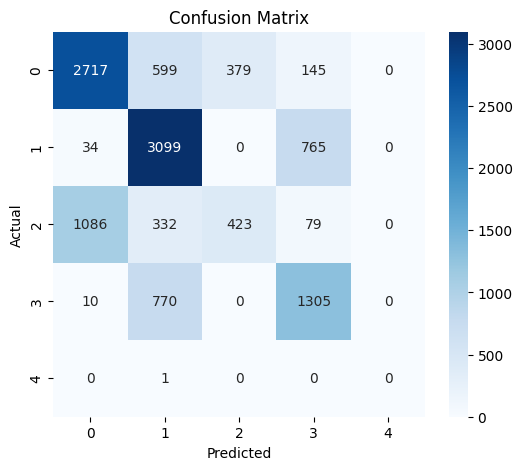

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()